## Further Adaptations

In [1]:
import socket
print(f"Running on: {socket.gethostname()}")

Running on: damnii03.inf.ed.ac.uk


In [2]:
# check CUDA available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

CUDA available: True
CUDA device count: 2
Current device: 0
Device name: NVIDIA GeForce RTX 2080 Ti


## Import Necessary Modules

In [5]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import T5Tokenizer, T5ForConditionalGeneration # huggingface T5 model + tokenizer
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import torchmetrics
from models.dynamic import FeatureProjector, MultitaskModelWithProjection, ProjectionExperimentDataset, create_experiment_pipeline, evaluate_with_sampling, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL
from sklearn.model_selection import train_test_split
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score
import nltk
import random
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import T5ForConditionalGeneration, T5Tokenizer

## Set Random Seed, For Reproducibility

In [4]:
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load Dataset and Extract Features

In [5]:
mwr_df = pd.read_csv('mwr.csv')

In [6]:
print(mwr_df.columns)

Index(['Examination ID', 'Conclusion', 'r:Th', 'Weight', 'Height',
       'Ambient temperature', 'r:AgeInYears', 'Mammary diameter', 'Cycle',
       'Day from the first day', 'Hormonal medications',
       'Cancer family history', 'Breast operations', 'Num of pregnancies',
       'R1 int', 'L1 int', 'R2 int', 'L2 int', 'R3 int', 'L3 int', 'R4 int',
       'L4 int', 'R5 int', 'L5 int', 'R6 int', 'L6 int', 'R7 int', 'L7 int',
       'R8 int', 'L8 int', 'R9 int', 'L9 int', 'T1 int', 'T2 int', 'R0 int',
       'L0 int', 'R1 sk', 'L1 sk', 'R2 sk', 'L2 sk', 'R3 sk', 'L3 sk', 'R4 sk',
       'L4 sk', 'R5 sk', 'L5 sk', 'R6 sk', 'L6 sk', 'R7 sk', 'L7 sk', 'R8 sk',
       'L8 sk', 'R9 sk', 'L9 sk', 'T1 sk', 'T2 sk', 'R0 sk', 'L0 sk',
       'Conclusion (Tr)', 'y_binary'],
      dtype='object')


In [7]:
# Select feature columns (temperature readings)
feature_cols = [col for col in mwr_df.columns if col.endswith('int') or col.endswith('sk')]
mwr_df['features'] = mwr_df[feature_cols].values.tolist()

# Prepare labels and text targets (binary classification)
mwr_df['class_label'] = mwr_df['y_binary'].astype(int)
mwr_df['synthetic_description'] = mwr_df['Conclusion (Tr)']

## Split Data into Test, Train and Validation

In [8]:
# 70% training, 15% validation, 15% testing
from sklearn.model_selection import train_test_split

# Stratified split on 'r:Th' column
train_df, temp_df = train_test_split(
    mwr_df, 
    test_size=0.3, 
    random_state=42, 
    stratify=mwr_df['r:Th']
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['r:Th']
)

## Dynamic Weighting

In [9]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=True,
        dynamic_loss_weighting=True,
        initial_class_weight=0.1,
        initial_gen_weight=10.0
    )


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp
Dynamic loss weighting: ENABLED
Initial weights - Classification: 0.1, Generation: 10.0


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes
  Dynamic loss weighting: True


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 4.7589
Classification loss: 0.6226
Generation loss: 2.5208
Weighted gen loss: 0.492226
Validation loss: 0.7498
Validation metrics:
  Accuracy     : 0.7459
  F1-Score     : 0.7200
  Sensitivity  : 0.8995
  Specificity  : 0.2645
  AUC-ROC      : 0.6829

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3774
  ✓ New best METEOR: 0.3774
  ROUGE-L F1   : 0.3854
  ✓ New best ROUGE-L F1: 0.3854
✓ New best accuracy: 0.7459
✓ New best F1: 0.7200
✓ New best AUC-ROC: 0.6829

Epoch 2/50
Training loss: 0.7942
Classification loss: 0.5523
Generation loss: 1.6877
Weighted gen loss: 0.402020
Validation loss: 0.7032
Validation metrics:
  Accuracy     : 0.7500
  F1-Score     : 0.7443
  Sensitivity  : 0.8544
  Specificity  : 0.4230
  AUC-ROC      : 0.7319

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
 

  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 17/50
Training loss: 0.5814
Classification loss: 0.4630
Generation loss: 0.7515
Weighted gen loss: 0.306841
Validation loss: 0.5651
Validation metrics:
  Accuracy     : 0.7677
  F1-Score     : 0.7718
  Sensitivity  : 0.8282
  Specificity  : 0.5781
  AUC-ROC      : 0.8024

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best F1: 0.7718
✓ New best AUC-ROC: 0.8024

Epoch 18/50
Training loss: 0.5777
Classification loss: 0.4609
Generation loss: 0.7424
Weighted gen loss: 0.308430
Validation loss: 0.5625
Validation metrics:
  Accuracy     : 0.7688
  F1-Score     : 0.7716
  Sensitivity  : 0.8355
  Specificity  : 0.5599
  AUC-ROC      : 0.7995

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
 

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7823
✓ New best F1: 0.7831
Current loss weights - CLF: 0.553, GEN: 0.447

Epoch 34/50
Training loss: 0.5321
Classification loss: 0.4341
Generation loss: 0.6511
Weighted gen loss: 0.306718
Validation loss: 0.5449
Validation metrics:
  Accuracy     : 0.7528
  F1-Score     : 0.7637
  Sensitivity  : 0.7823
  Specificity  : 0.6602
  AUC-ROC      : 0.8111

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 35/50
Training loss: 0.5352
Classification loss: 0.4359
Generation loss: 0.6476
Weighted gen loss: 0.303882
Validation loss: 0.5239
Validation metrics:
  Accuracy     : 0.7779
  F1-Score     : 0.7820
  Sensitivity  : 0.8344
  Specificity  : 0.6009
  AUC-ROC      : 0.8235

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL d

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145


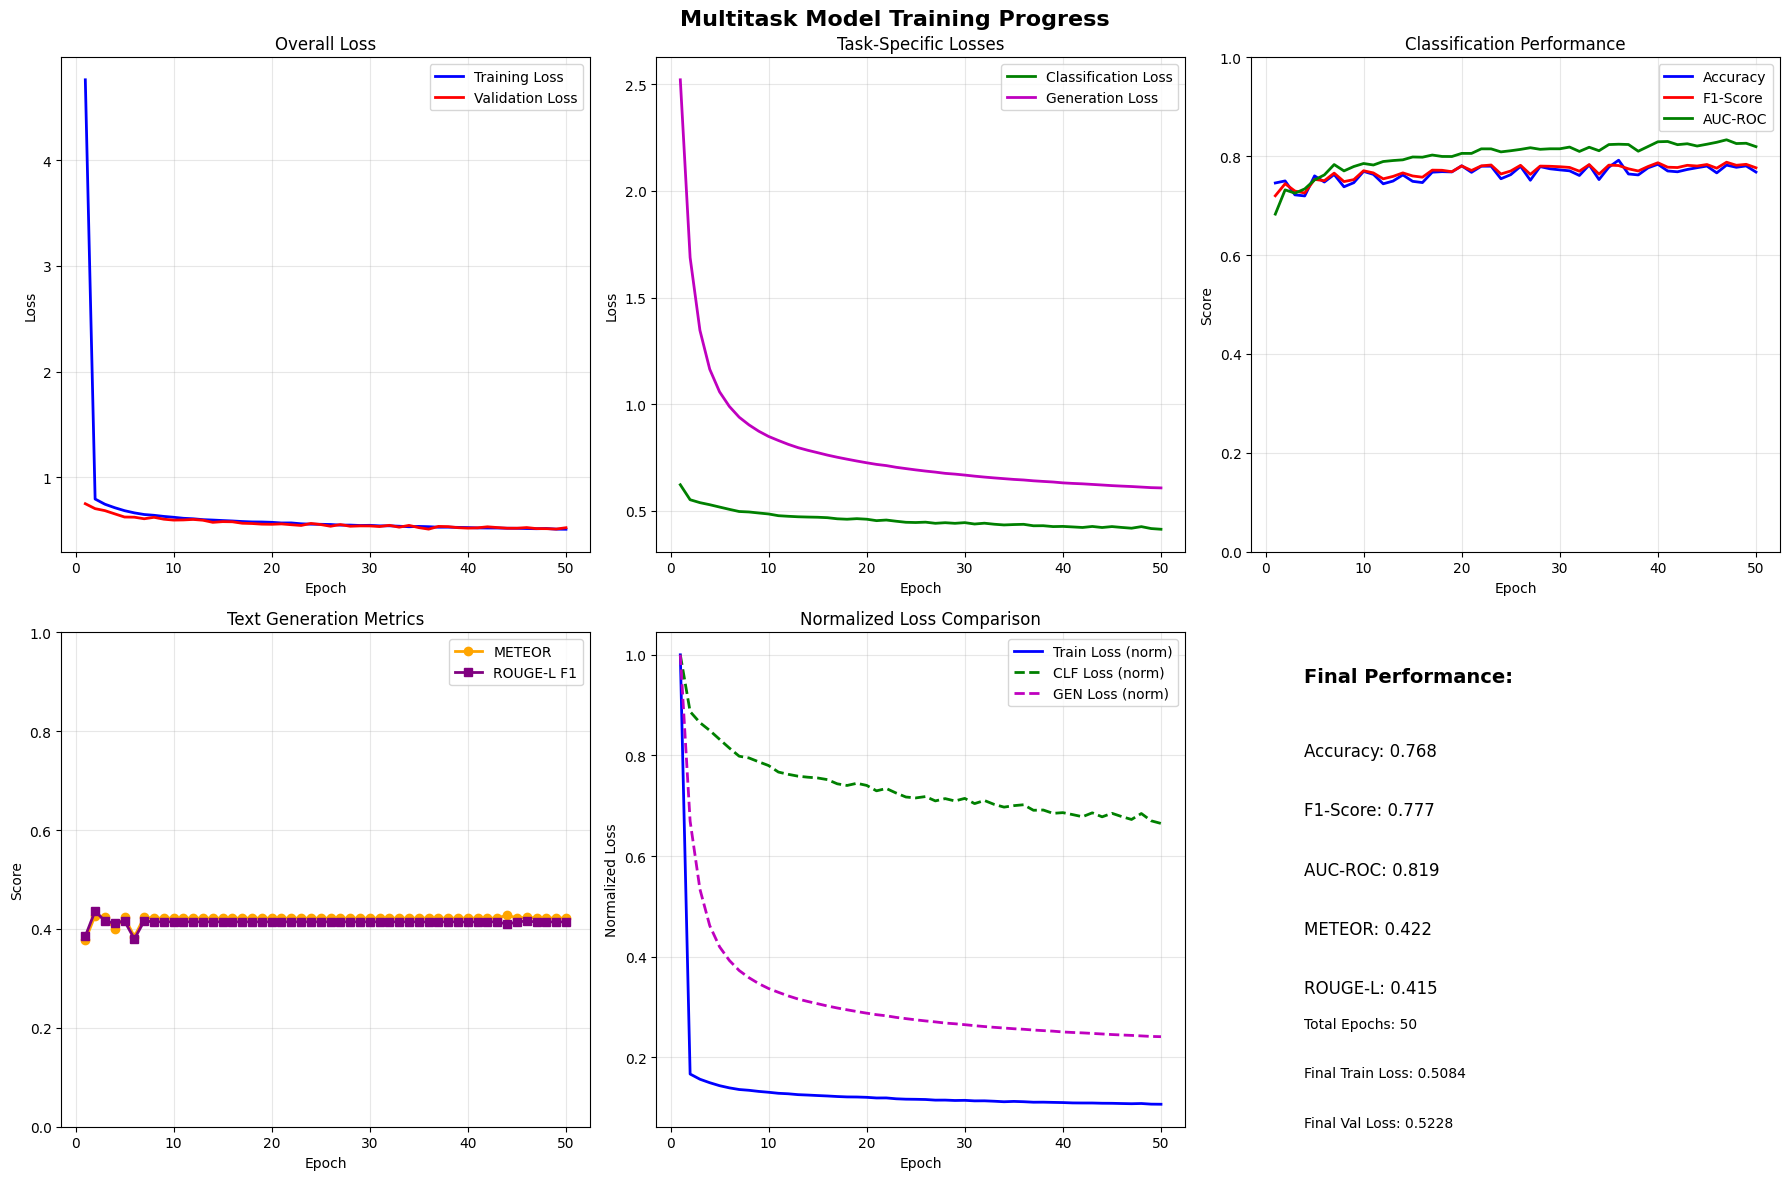


TRAINING SUMMARY
Best Accuracy: 0.7919
Best F1-Score: 0.7879
Best AUC-ROC: 0.8332
Best METEOR: 0.4279
Best ROUGE-L: 0.4366


In [10]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.5092
Classification metrics (all 3625 samples):
  Accuracy     : 0.7788
  F1-Score     : 0.7864
  Sensitivity  : 0.8148
  Specificity  : 0.6655
  AUC-ROC      : 0.8382

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4130
  METEOR       : 0.4206

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a specialist doctor and
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan measurement in one year. In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a

## Adapter Modules

In [9]:
# import adapter modules
from models.adapter import FeatureProjector, MultitaskModelWithAdapters, ProjectionExperimentDataset, create_experiment_pipeline, evaluate_with_sampling, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=True,
        use_adapters=True,
        adapter_dim=64,
        adapter_dropout=0.1,
        freeze_t5_weights=True
    )


EXPERIMENT: CONCAT projection + MINIMAL text
Projection type: mlp
Adapters: ENABLED
Adapter dim: 64, dropout: 0.1
T5 weights: FROZEN


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: True
  Feature projection: Yes
  Adapters: True
  Trainable parameters: 3,242,506 / 63,749,130 (5.1%)


### Train Model


Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 24.7746
Classification loss: 0.6163
Generation loss: 2.4713
Weighted gen loss: 24.712988
Validation loss: 13.8910
Validation metrics:
  Accuracy     : 0.7307
  F1-Score     : 0.7287
  Sensitivity  : 0.8289
  Specificity  : 0.4230
  AUC-ROC      : 0.6976

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.3774
  ✓ New best METEOR: 0.3774
  ROUGE-L F1   : 0.3854
  ✓ New best ROUGE-L F1: 0.3854
✓ New best accuracy: 0.7307
✓ New best F1: 0.7287
✓ New best AUC-ROC: 0.6976

Epoch 2/50
Training loss: 14.5488
Classification loss: 0.5558
Generation loss: 1.4493
Weighted gen loss: 14.493242
Validation loss: 11.7300
Validation metrics:
  Accuracy     : 0.7337
  F1-Score     : 0.7383
  Sensitivity  : 0.8067
  Specificity  : 0.5051
  AUC-ROC      : 0.7294

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 sample

Training loss: 9.1306
Classification loss: 0.4598
Generation loss: 0.9085
Weighted gen loss: 9.084619
Validation loss: 8.0748
Validation metrics:
  Accuracy     : 0.7525
  F1-Score     : 0.7640
  Sensitivity  : 0.7776
  Specificity  : 0.6739
  AUC-ROC      : 0.8080

--- Text Evaluation (Epoch 16) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best AUC-ROC: 0.8080

Epoch 17/50
Training loss: 9.0443
Classification loss: 0.4654
Generation loss: 0.8998
Weighted gen loss: 8.997773
Validation loss: 7.9194
Validation metrics:
  Accuracy     : 0.7627
  F1-Score     : 0.7698
  Sensitivity  : 0.8100
  Specificity  : 0.6146
  AUC-ROC      : 0.8069

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 18/50
Training loss: 8.9481
Classification loss: 0.45

Computing text metrics on 3624 samples...
  METEOR Score : 0.3750
  ROUGE-L F1   : 0.3698

Epoch 33/50
Training loss: 8.1711
Classification loss: 0.4325
Generation loss: 0.8128
Weighted gen loss: 8.127872
Validation loss: 7.3853
Validation metrics:
  Accuracy     : 0.7867
  F1-Score     : 0.7891
  Sensitivity  : 0.8482
  Specificity  : 0.5941
  AUC-ROC      : 0.8292

--- Text Evaluation (Epoch 33) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best accuracy: 0.7867
✓ New best F1: 0.7891
✓ New best AUC-ROC: 0.8292
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 34/50
Training loss: 8.1418
Classification loss: 0.4317
Generation loss: 0.8099
Weighted gen loss: 8.098655
Validation loss: 7.3964
Validation metrics:
  Accuracy     : 0.7798
  F1-Score     : 0.7813
  Sensitivity  : 0.8482
  Specificity  : 0.5656
  AUC-ROC      : 0.8252

--- Text Evaluation (Epoch 34) ---
Evaluati

Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ROUGE-L F1   : 0.4143

Epoch 50/50
Training loss: 7.7151
Classification loss: 0.4181
Generation loss: 0.7673
Weighted gen loss: 7.673338
Validation loss: 7.0419
Validation metrics:
  Accuracy     : 0.7853
  F1-Score     : 0.7857
  Sensitivity  : 0.8566
  Specificity  : 0.5621
  AUC-ROC      : 0.8297

--- Text Evaluation (Epoch 50) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4234
  ROUGE-L F1   : 0.4143


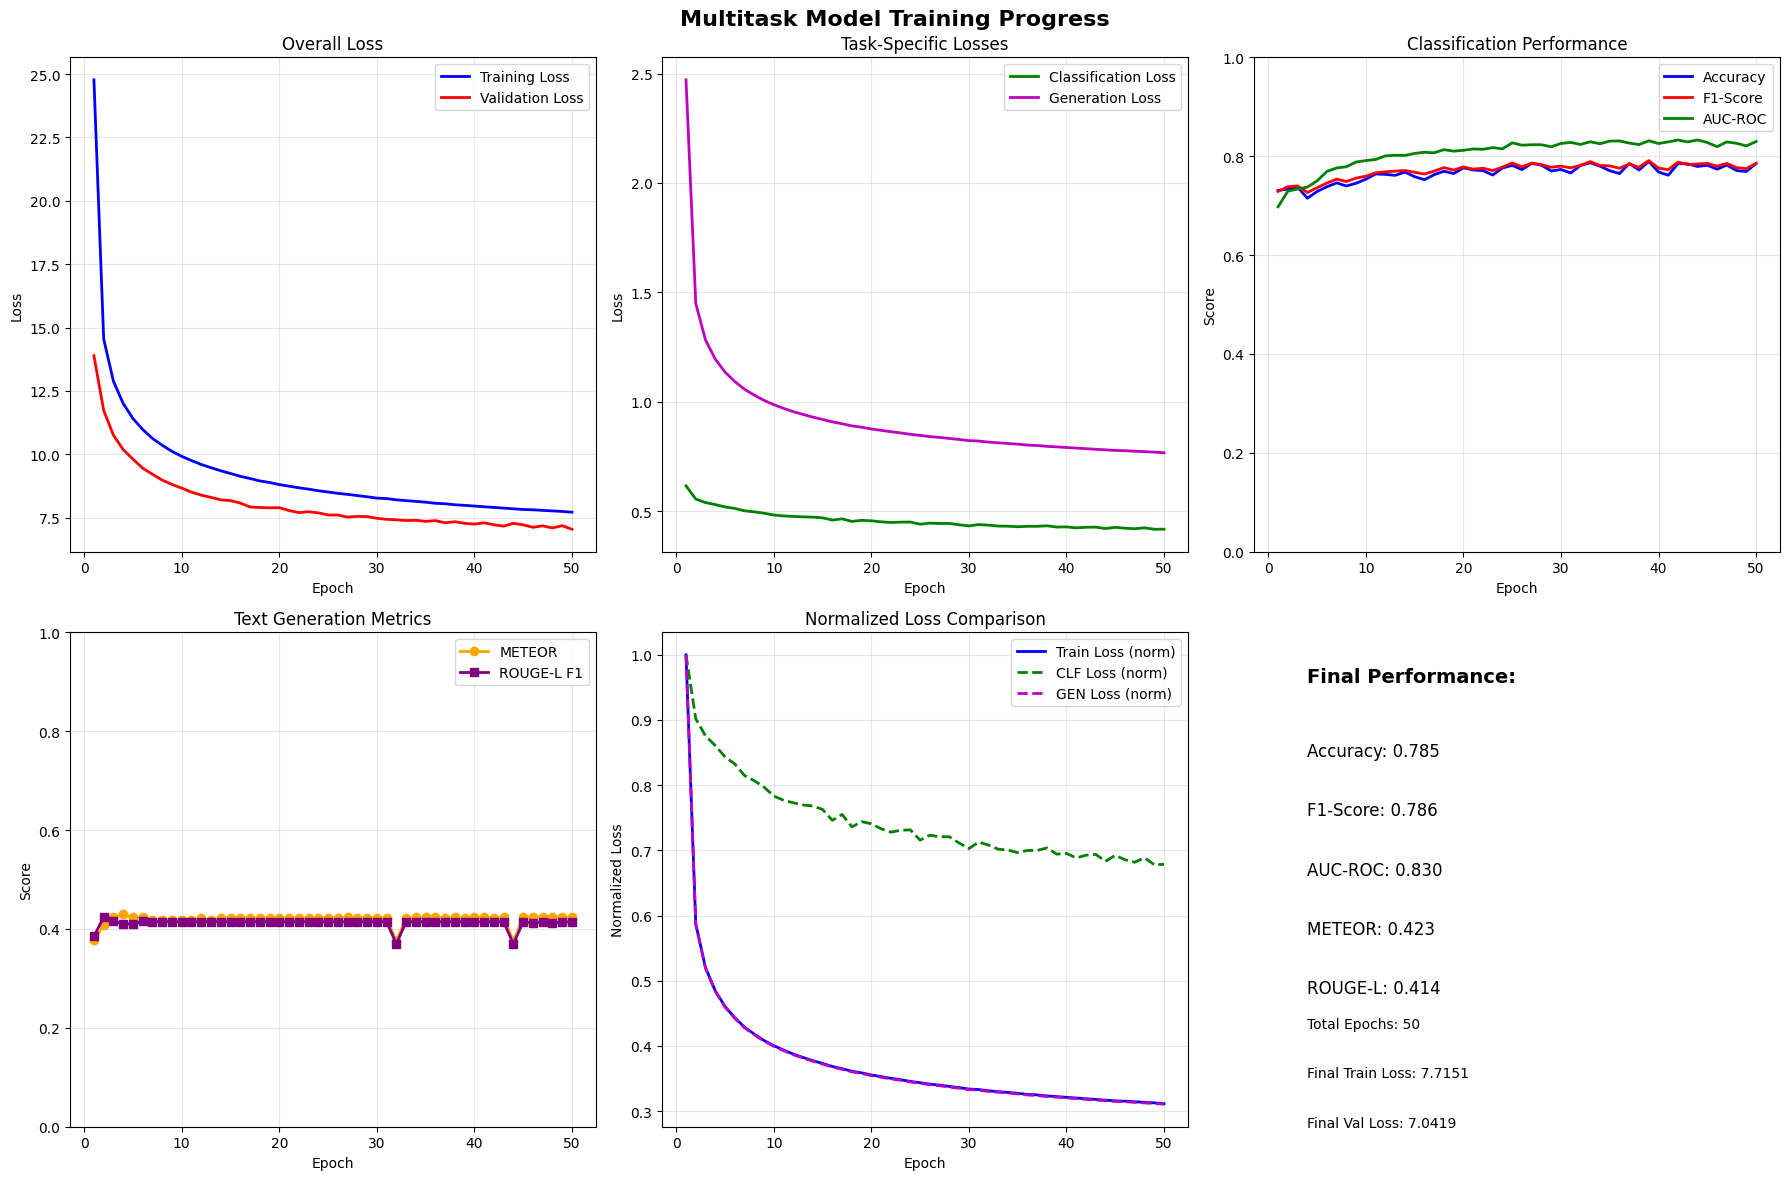


TRAINING SUMMARY
Best Accuracy: 0.7895
Best F1-Score: 0.7912
Best AUC-ROC: 0.8328
Best METEOR: 0.4293
Best ROUGE-L: 0.4237


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

### Test Model and Display Text Generation Sample

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.9634
Classification metrics (all 3625 samples):
  Accuracy     : 0.8055
  F1-Score     : 0.8061
  Sensitivity  : 0.8690
  Specificity  : 0.6062
  AUC-ROC      : 0.8476

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4123
  METEOR       : 0.4209

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (May 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations and a follow-up breast scan in one year (May 2011). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a clinical examination by a
Reference : The measu

## Hierarchical Architecture

In [9]:
# import hierarchical modules
from models.hierarchy import (
    HierarchicalFeatureEncoder,        
    HierarchicalClassifier,           
    MLPFeatureProjector,              
    HierarchicalMultitaskModel,       
    HierarchicalDataset,              
    create_hierarchical_pipeline
)

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_hierarchical_pipeline(
    df_train=train_df,
    df_val=val_df, 
    df_test=test_df,          
    tokenizer_path='./t5-small-local/',
    batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    classification_weight=1.0,
    generation_weight=10.0,
)


HIERARCHICAL MULTITASK MODEL
Architecture: Hierarchical encoder + Concat projection + MLP + Minimal text
Classification weight: 1.0
Generation weight: 10.0


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Hierarchical levels: 3 + integration
  Projection mode: concat + MLP
  Text mode: minimal
  Feature dimensions: L1=256, L2=512, L3=512



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 23.5620
Classification loss: 0.5774
Generation loss: 2.2985
Weighted gen loss: 22.984586
Validation loss: 12.6099
Validation metrics:
  Accuracy     : 0.7555
  F1-Score     : 0.7475
  Sensitivity  : 0.8657
  Specificity  : 0.4105
  AUC-ROC      : 0.7343

--- Text Evaluation (Epoch 1) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4236
  ✓ New best METEOR: 0.4236
  ROUGE-L F1   : 0.4157
  ✓ New best ROUGE-L F1: 0.4157
✓ New best accuracy: 0.7555
✓ New best F1: 0.7475
✓ New best AUC-ROC: 0.7343

Epoch 2/50
Training loss: 13.4312
Classification loss: 0.5218
Generation loss: 1.2909
Weighted gen loss: 12.909374
Validation loss: 10.7889
Validation metrics:
  Accuracy     : 0.7442
  F1-Score     : 0.7484
  Sensitivity  : 0.8147
  Specificity  : 0.5234
  AUC-ROC      : 0.7576

--- Text Evaluation (Epoch 2) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 sample

  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Epoch 17/50
Training loss: 8.4401
Classification loss: 0.4454
Generation loss: 0.7995
Weighted gen loss: 7.994749
Validation loss: 7.7217
Validation metrics:
  Accuracy     : 0.7569
  F1-Score     : 0.7666
  Sensitivity  : 0.7921
  Specificity  : 0.6465
  AUC-ROC      : 0.8071

--- Text Evaluation (Epoch 17) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best AUC-ROC: 0.8071

Epoch 18/50
Training loss: 8.3445
Classification loss: 0.4407
Generation loss: 0.7904
Weighted gen loss: 7.903754
Validation loss: 7.6726
Validation metrics:
  Accuracy     : 0.7591
  F1-Score     : 0.7659
  Sensitivity  : 0.8103
  Specificity  : 0.5986
  AUC-ROC      : 0.8051

--- Text Evaluation (Epoch 18) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145

Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
Current loss weights - CLF: 1.000, GEN: 10.000

Epoch 34/50
Training loss: 7.4117
Classification loss: 0.4078
Generation loss: 0.7004
Weighted gen loss: 7.003880
Validation loss: 7.0030
Validation metrics:
  Accuracy     : 0.7679
  F1-Score     : 0.7770
  Sensitivity  : 0.8009
  Specificity  : 0.6648
  AUC-ROC      : 0.8282

--- Text Evaluation (Epoch 34) ---
Evaluating text generation on FULL dataset (3624 samples)
Computing text metrics on 3624 samples...
  METEOR Score : 0.4221
  ROUGE-L F1   : 0.4145
✓ New best F1: 0.7770
✓ New best AUC-ROC: 0.8282

Epoch 35/50
Training loss: 7.3728
Classification loss: 0.4053
Generation loss: 0.6968
Weighted gen loss: 6.967517
Validation loss: 6.9778
Validation metrics:
  Accuracy     : 0.7688
  F1-Score     : 0.7765
  Sensitivity  : 0.8092
  Specificity  : 0.6420
  AUC-ROC      : 0.8189

--- Text Evaluation (Epoch 35) ---
Evaluating text generation on FULL d

Computing text metrics on 3624 samples...
  METEOR Score : 0.3647
  ROUGE-L F1   : 0.3742
✓ New best AUC-ROC: 0.8314


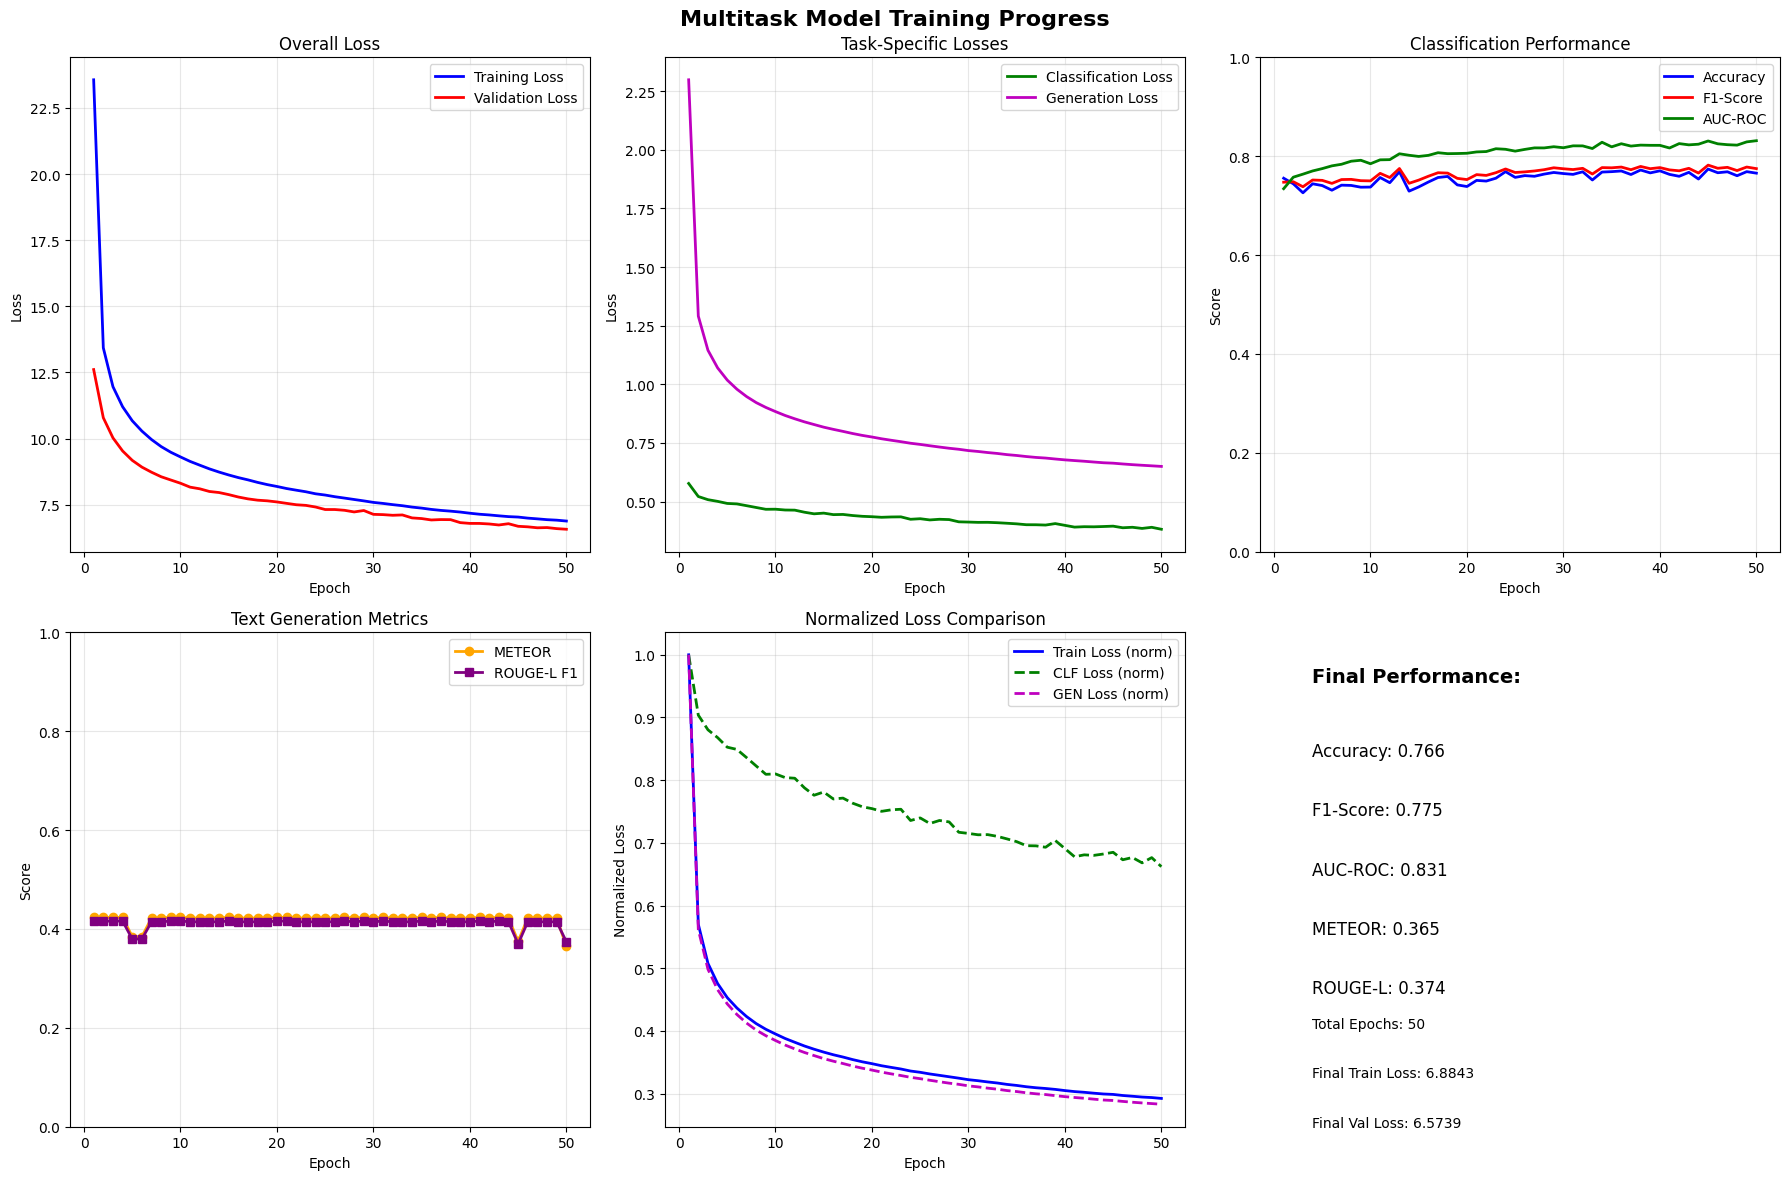


TRAINING SUMMARY
Best Accuracy: 0.7740
Best F1-Score: 0.7820
Best AUC-ROC: 0.8314
Best METEOR: 0.4236
Best ROUGE-L: 0.4160


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=1
)

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.4940
Classification metrics (all 3625 samples):
  Accuracy     : 0.7834
  F1-Score     : 0.7917
  Sensitivity  : 0.8123
  Specificity  : 0.6929
  AUC-ROC      : 0.8480

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3736
  METEOR       : 0.3647

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=20)


Displaying 20 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast scan measurement in a year. In
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast scan measurement in a year. In

In [9]:
# concat full text dynamic weighting

In [10]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=False,
        dynamic_loss_weighting=True,
        initial_class_weight=0.1,
        initial_gen_weight=10.0
    )


EXPERIMENT: CONCAT projection + FULL text
Projection type: mlp
Dynamic loss weighting: ENABLED
Initial weights - Classification: 0.1, Generation: 10.0


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: False
  Feature projection: Yes
  Dynamic loss weighting: True



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 4.3261
Classification loss: 0.6283
Generation loss: 2.2857
Weighted gen loss: 0.481555
Validation loss: 0.7401
Validation metrics:
  Accuracy     : 0.7310
  F1-Score     : 0.7271
  Sensitivity  : 0.8351
  Specificity  : 0.4048
  AUC-ROC      : 0.7033
✓ New best accuracy: 0.7310
✓ New best F1: 0.7271
✓ New best AUC-ROC: 0.7033

Epoch 2/50
Training loss: 0.7892
Classification loss: 0.5532
Generation loss: 1.5859
Weighted gen loss: 0.399167
Validation loss: 0.6956
Validation metrics:
  Accuracy     : 0.7285
  F1-Score     : 0.7236
  Sensitivity  : 0.8365
  Specificity  : 0.3900
  AUC-ROC      : 0.7179
✓ New best AUC-ROC: 0.7179

Epoch 3/50
Training loss: 0.7315
Classification loss: 0.5332
Generation loss: 1.2886
Weighted gen loss: 0.380214
Validation loss: 0.6838
Validation metrics:
  Accuracy     : 0.7163
  F1-Score     : 0.7235
  Sensitivity  : 0.7856
  Specificity  : 0.4994
  AUC-ROC      : 0.7279
✓ New best AUC-ROC: 0.7279
Current loss weights - CLF: 0.705, GEN: 0.295



Validation loss: 0.5342
Validation metrics:
  Accuracy     : 0.7787
  F1-Score     : 0.7788
  Sensitivity  : 0.8537
  Specificity  : 0.5439
  AUC-ROC      : 0.8080

Epoch 27/50
Training loss: 0.5425
Classification loss: 0.4462
Generation loss: 0.6579
Weighted gen loss: 0.293975
Validation loss: 0.5396
Validation metrics:
  Accuracy     : 0.7610
  F1-Score     : 0.7693
  Sensitivity  : 0.8027
  Specificity  : 0.6306
  AUC-ROC      : 0.8083
Current loss weights - CLF: 0.553, GEN: 0.447

Epoch 28/50
Training loss: 0.5409
Classification loss: 0.4471
Generation loss: 0.6523
Weighted gen loss: 0.295921
Validation loss: 0.5252
Validation metrics:
  Accuracy     : 0.7804
  F1-Score     : 0.7733
  Sensitivity  : 0.8813
  Specificity  : 0.4641
  AUC-ROC      : 0.8082

Epoch 29/50
Training loss: 0.5373
Classification loss: 0.4441
Generation loss: 0.6483
Weighted gen loss: 0.295529
Validation loss: 0.5320
Validation metrics:
  Accuracy     : 0.7712
  F1-Score     : 0.7772
  Sensitivity  : 0.8209
 

/home/s2080063/MWR-to-Text/dynamic.py:1062: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


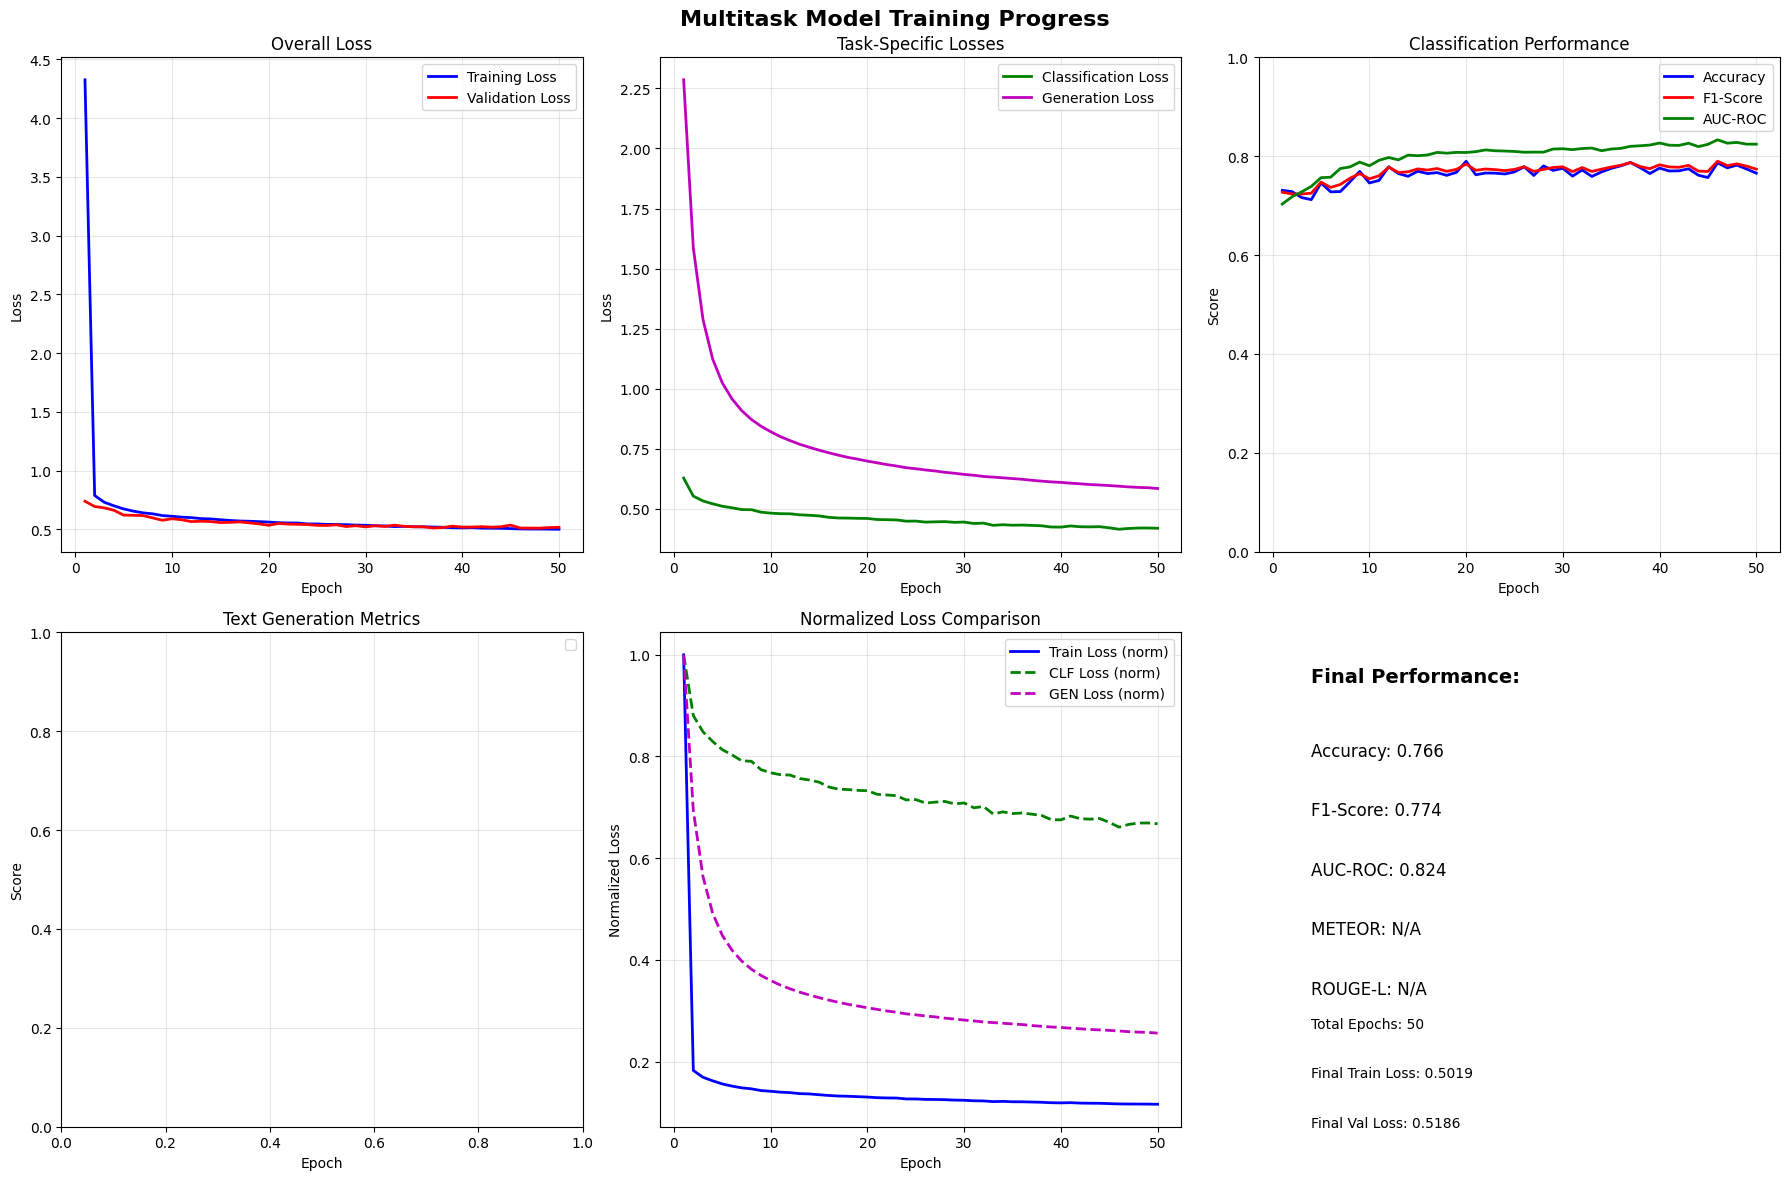


TRAINING SUMMARY
Best Accuracy: 0.7897
Best F1-Score: 0.7900
Best AUC-ROC: 0.8332


In [11]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [12]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.5053
Classification metrics (all 3625 samples):
  Accuracy     : 0.7903
  F1-Score     : 0.7971
  Sensitivity  : 0.8258
  Specificity  : 0.6792
  AUC-ROC      : 0.8437

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4024
  METEOR       : 0.4054

Sample efficiency: 3625/3625 samples used for text metrics


In [13]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but currently does not indicate signs of locally elevated metabolism in breast tissue. We recommend regular self-examinations, regular recommended preventive check-ups with a specialist, and additional diagnostics according to their opinion, as well as a repeat breast
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, the asymmetry on the surface is currently exceeded, it can be observed that the entire right breast is cooler. We recommend that the lady undergo a preventive breast ultrasound and perform regular self-examinations. Breastscan control by appointment,

In [14]:
# prefix full text dynamic weighting

In [40]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='prefix',
        projection_type='linear',
        use_minimal_text=False,
        dynamic_loss_weighting=True,
        initial_class_weight=0.1,
        initial_gen_weight=10.0
    )


EXPERIMENT: PREFIX projection + FULL text
Projection type: linear
Dynamic loss weighting: ENABLED
Initial weights - Classification: 0.1, Generation: 10.0
Using device: cuda
Model configuration:
  Projection mode: prefix
  Projection type: linear
  Minimal text: False
  Feature projection: Yes
  Dynamic loss weighting: True



Epoch 1/50
Training loss: 4.5404
Classification loss: 0.7560
Generation loss: 2.2204
Weighted gen loss: 0.487887
Validation loss: 0.7182
Validation metrics:
  Accuracy     : 0.7431
  F1-Score     : 0.7017
  Sensitivity  : 0.9228
  Specificity  : 0.1802
  AUC-ROC      : 0.6837
✓ New best accuracy: 0.7431
✓ New best F1: 0.7017
✓ New best AUC-ROC: 0.6837

Epoch 2/50
Training loss: 0.7819
Classification loss: 0.5566
Generation loss: 1.4858
Weighted gen loss: 0.395668
Validation loss: 0.6789
Validation metrics:
  Accuracy     : 0.7541
  F1-Score     : 0.7342
  Sensitivity  : 0.8944
  Specificity  : 0.3147
  AUC-ROC      : 0.7203
✓ New best accuracy: 0.7541
✓ New best F1: 0.7342
✓ New best AUC-ROC: 0.7203

Epoch 3/50
Training loss: 0.7272
Classification loss: 0.5344
Generation loss: 1.2271
Weighted gen loss: 0.368321
Validation loss: 0.6504
Validation metrics:
  Accuracy     : 0.7566
  F1-Score     : 0.7467
  Sensitivity  : 0.8719
  Specificity  : 0.3957
  AUC-ROC      : 0.7401
✓ New best a

Training loss: 0.5465
Classification loss: 0.4484
Generation loss: 0.6670
Weighted gen loss: 0.294228
Validation loss: 0.5316
Validation metrics:
  Accuracy     : 0.7770
  F1-Score     : 0.7789
  Sensitivity  : 0.8446
  Specificity  : 0.5656
  AUC-ROC      : 0.8168
✓ New best AUC-ROC: 0.8168

Epoch 27/50
Training loss: 0.5444
Classification loss: 0.4485
Generation loss: 0.6617
Weighted gen loss: 0.285808
Validation loss: 0.5214
Validation metrics:
  Accuracy     : 0.7886
  F1-Score     : 0.7818
  Sensitivity  : 0.8871
  Specificity  : 0.4800
  AUC-ROC      : 0.8145
✓ New best accuracy: 0.7886
Current loss weights - CLF: 0.568, GEN: 0.432

Epoch 28/50
Training loss: 0.5399
Classification loss: 0.4434
Generation loss: 0.6568
Weighted gen loss: 0.302838
Validation loss: 0.5276
Validation metrics:
  Accuracy     : 0.7784
  F1-Score     : 0.7783
  Sensitivity  : 0.8544
  Specificity  : 0.5405
  AUC-ROC      : 0.8170
✓ New best AUC-ROC: 0.8170

Epoch 29/50
Training loss: 0.5393
Classificatio

/home/s2080063/MWR-to-Text/dynamic.py:1062: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


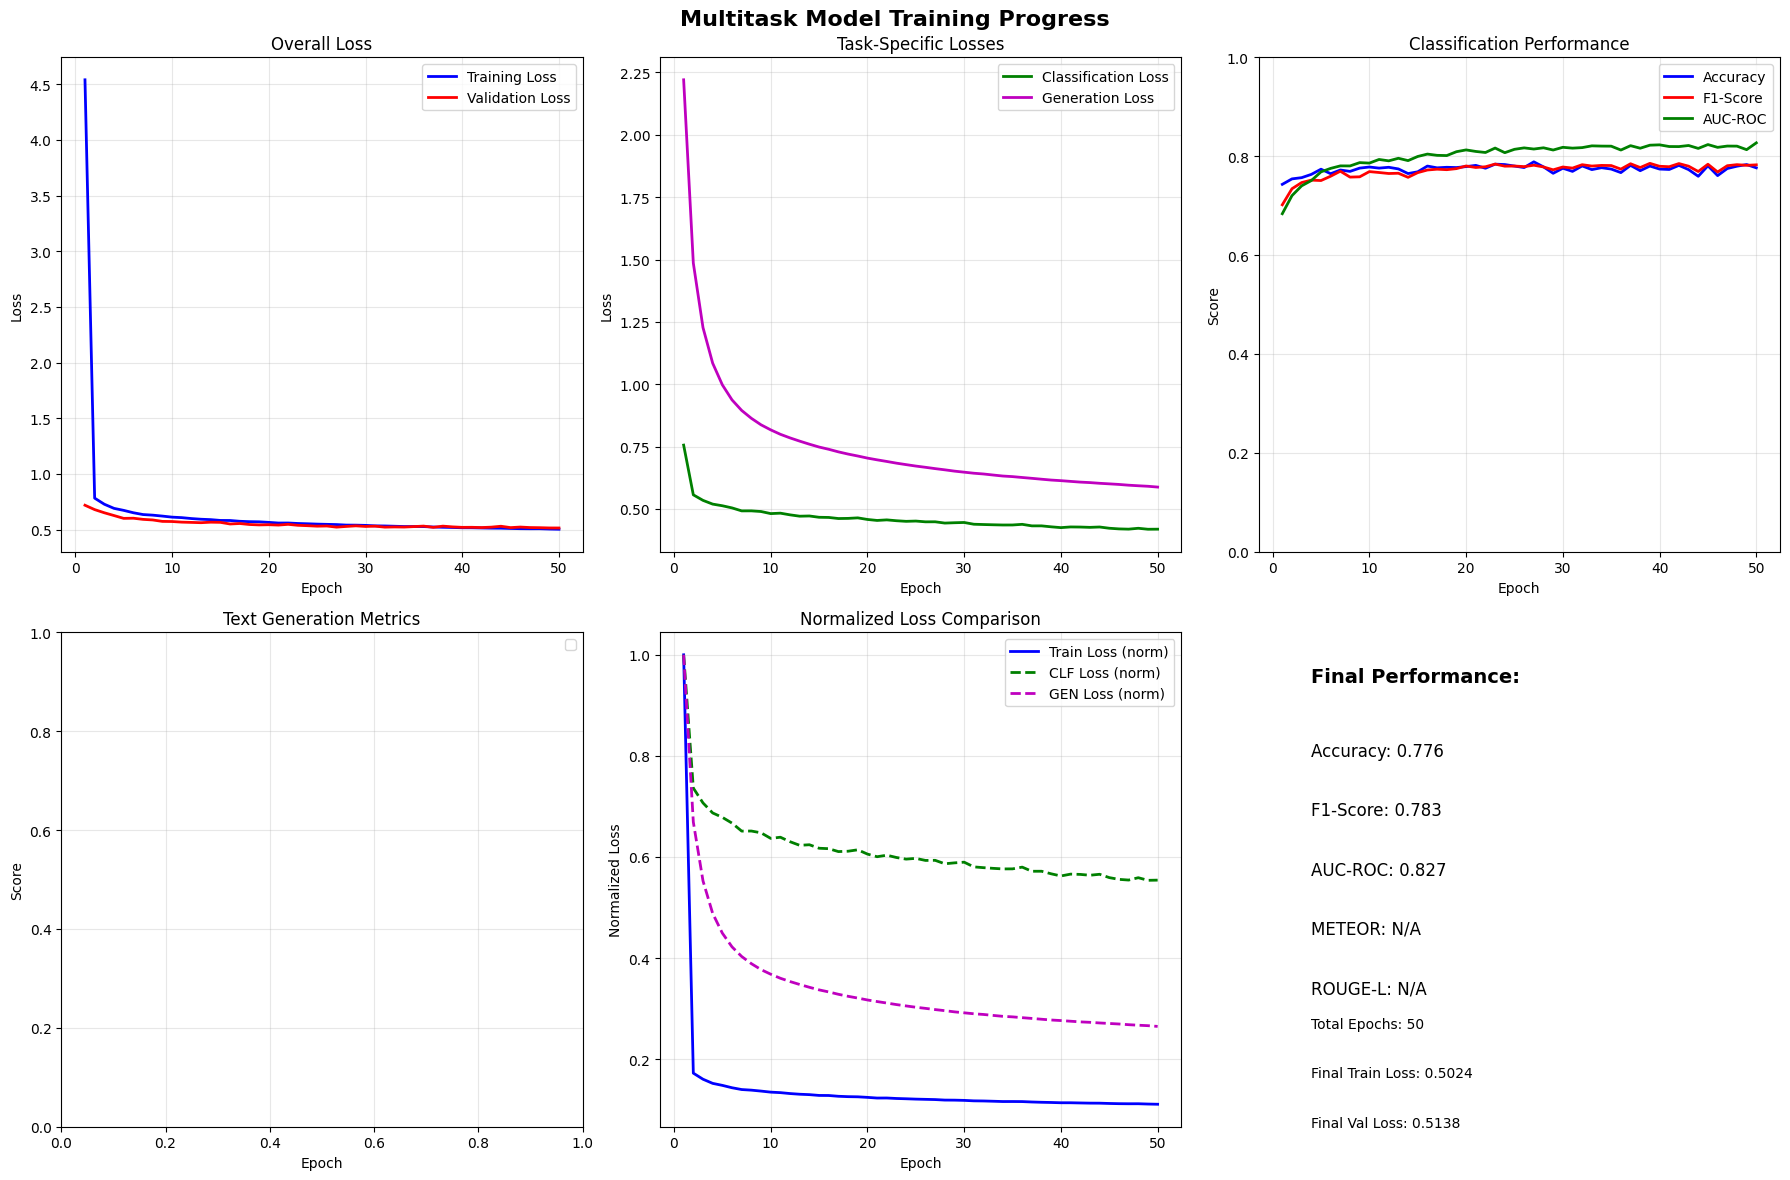


TRAINING SUMMARY
Best Accuracy: 0.7886
Best F1-Score: 0.7856
Best AUC-ROC: 0.8270


In [41]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [42]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 0.5017
Classification metrics (all 3625 samples):
  Accuracy     : 0.7997
  F1-Score     : 0.8049
  Sensitivity  : 0.8403
  Specificity  : 0.6724
  AUC-ROC      : 0.8448

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3842
  METEOR       : 0.3780

Sample efficiency: 3625/3625 samples used for text metrics


In [43]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate locally elevated metabolism in breast tissue. A follow-up is recommended in 1 year (June 2012). During this period, we advise monthly self-examinations and preventive mammography (which has not been done since 2005
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature does not indicate signs of locally increased metabolism in the breast tissue. We recommend a follow-up in 1 year (December 2011). During this period, we advise monthly self-examinations. In the case of any noticeable changes, discharge, or prolonged pain, please schedule an earlier
Reference : The measured tempe

In [28]:
from models.adapter import FeatureProjector, MultitaskModelWithAdapters, ProjectionExperimentDataset, create_experiment_pipeline, evaluate_with_sampling, train, train_and_validate_model_with_meteor_rouge, train_and_validate_model_with_meteor_stopping, METEOREarlyStopping, display_generated_texts, print_test_evaluation, compute_rougeL

In [29]:
# concat full text + adapter modules

In [30]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='concat',
        projection_type='mlp',
        use_minimal_text=False,
        use_adapters=True,
        adapter_dim=64,
        adapter_dropout=0.1,
        freeze_t5_weights=True
    )


EXPERIMENT: CONCAT projection + FULL text
Projection type: mlp
Adapters: ENABLED
Adapter dim: 64, dropout: 0.1
T5 weights: FROZEN
Using device: cuda
Model configuration:
  Projection mode: concat
  Projection type: mlp
  Minimal text: False
  Feature projection: Yes
  Adapters: True
  Trainable parameters: 3,242,506 / 63,749,130 (5.1%)



Epoch 1/50
Training loss: 23.5575
Classification loss: 0.6054
Generation loss: 2.3497
Weighted gen loss: 23.496918
Validation loss: 13.7803
Validation metrics:
  Accuracy     : 0.7384
  F1-Score     : 0.7295
  Sensitivity  : 0.8551
  Specificity  : 0.3729
  AUC-ROC      : 0.7041
✓ New best accuracy: 0.7384
✓ New best F1: 0.7295
✓ New best AUC-ROC: 0.7041

Epoch 2/50
Training loss: 14.3902
Classification loss: 0.5602
Generation loss: 1.4334
Weighted gen loss: 14.334213
Validation loss: 11.6078
Validation metrics:
  Accuracy     : 0.7329
  F1-Score     : 0.7365
  Sensitivity  : 0.8103
  Specificity  : 0.4903
  AUC-ROC      : 0.7185
✓ New best F1: 0.7365
✓ New best AUC-ROC: 0.7185

Epoch 3/50
Training loss: 12.7052
Classification loss: 0.5417
Generation loss: 1.2651
Weighted gen loss: 12.651050
Validation loss: 10.6362
Validation metrics:
  Accuracy     : 0.7514
  F1-Score     : 0.7471
  Sensitivity  : 0.8511
  Specificity  : 0.4390
  AUC-ROC      : 0.7355
✓ New best accuracy: 0.7514
✓ N

Validation loss: 7.5481
Validation metrics:
  Accuracy     : 0.7536
  F1-Score     : 0.7649
  Sensitivity  : 0.7798
  Specificity  : 0.6716
  AUC-ROC      : 0.8191

Epoch 26/50
Training loss: 8.3278
Classification loss: 0.4453
Generation loss: 0.8283
Weighted gen loss: 8.283286
Validation loss: 7.4440
Validation metrics:
  Accuracy     : 0.7724
  F1-Score     : 0.7783
  Sensitivity  : 0.8216
  Specificity  : 0.6180
  AUC-ROC      : 0.8266
✓ New best AUC-ROC: 0.8266

Epoch 27/50
Training loss: 8.2804
Classification loss: 0.4420
Generation loss: 0.8236
Weighted gen loss: 8.236221
Validation loss: 7.4462
Validation metrics:
  Accuracy     : 0.7597
  F1-Score     : 0.7696
  Sensitivity  : 0.7914
  Specificity  : 0.6602
  AUC-ROC      : 0.8195
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 8.2378
Classification loss: 0.4407
Generation loss: 0.8194
Weighted gen loss: 8.193715
Validation loss: 7.4696
Validation metrics:
  Accuracy     : 0.7724
  F1-Score     : 0.77

/home/s2080063/MWR-to-Text/adapter.py:1156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


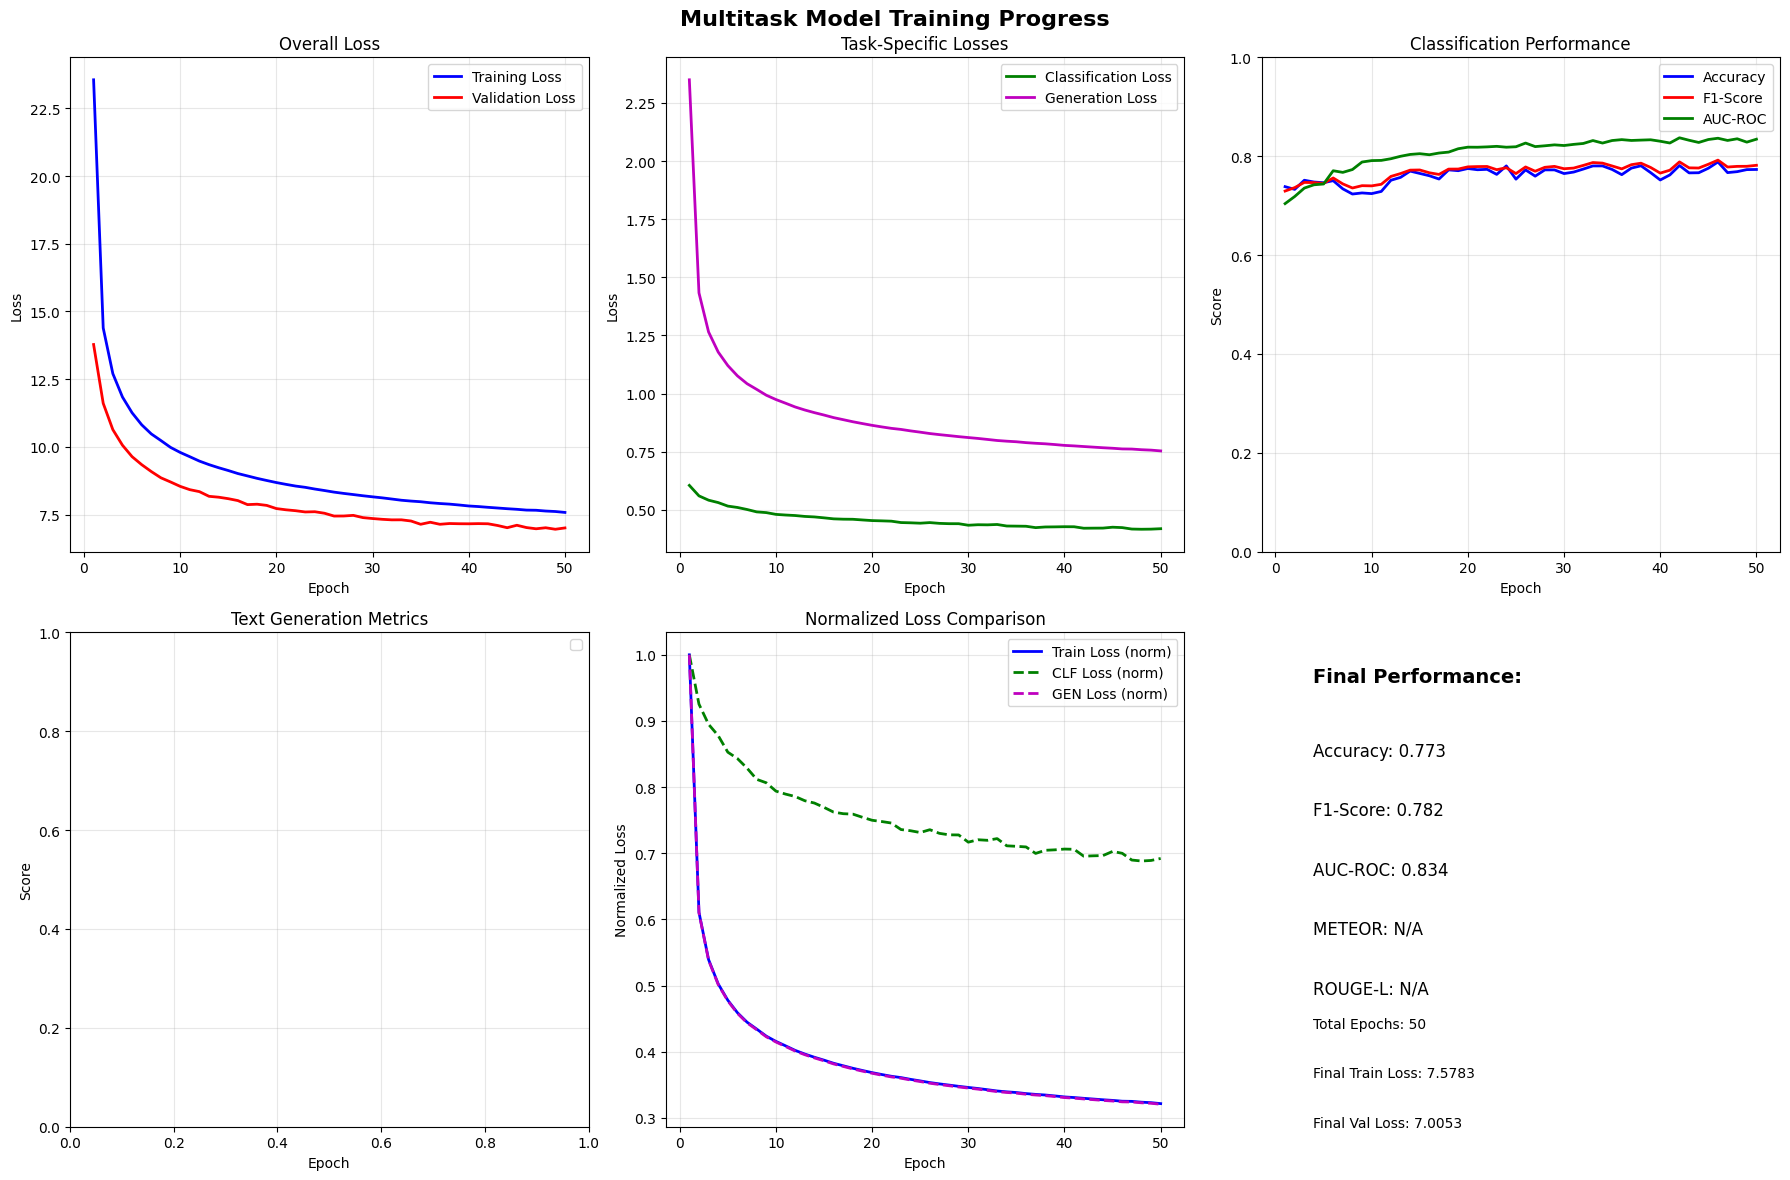


TRAINING SUMMARY
Best Accuracy: 0.7884
Best F1-Score: 0.7921
Best AUC-ROC: 0.8373


In [31]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [32]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.9634
Classification metrics (all 3625 samples):
  Accuracy     : 0.7967
  F1-Score     : 0.8042
  Sensitivity  : 0.8232
  Specificity  : 0.7135
  AUC-ROC      : 0.8555

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.4021
  METEOR       : 0.4045

Sample efficiency: 3625/3625 samples used for text metrics


In [33]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 3060
----------------------------------------
Generated : The measured temperature does not indicate signs of locally elevated metabolism in the breast tissue. We recommend regular self-examinations, regular recommended clinical check-ups with a specialist, and additional diagnostics as deemed necessary by them, as well as a repeat breast scan measurement in one year (09.
Reference : The measured temperature values are exceeded. It is still noticeable that the entire right breast is cooler.
----------------------------------------

Sample 2395
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate signs of locally increased metabolism in the breast tissue. We recommend the next check-up in 1 year (01. 2014). During this period, we advise regular self-examination. In the case of noticeable, visible changes, discharge,
Reference : The measured asym

In [ ]:
# prefix full text + adapter modules

In [34]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_experiment_pipeline(
        train_df,
        val_df, 
        test_df,
        projection_mode='prefix',
        projection_type='linear',
        use_minimal_text=False,
        use_adapters=True,
        adapter_dim=64,
        adapter_dropout=0.1,
        freeze_t5_weights=True
    )


EXPERIMENT: PREFIX projection + FULL text
Projection type: linear
Adapters: ENABLED
Adapter dim: 64, dropout: 0.1
T5 weights: FROZEN
Using device: cuda
Model configuration:
  Projection mode: prefix
  Projection type: linear
  Minimal text: False
  Feature projection: Yes
  Adapters: True
  Trainable parameters: 2,455,050 / 62,961,674 (3.9%)



Epoch 1/50
Training loss: 23.7429
Classification loss: 0.5961
Generation loss: 2.3683
Weighted gen loss: 23.683271
Validation loss: 13.6467
Validation metrics:
  Accuracy     : 0.7307
  F1-Score     : 0.7206
  Sensitivity  : 0.8526
  Specificity  : 0.3489
  AUC-ROC      : 0.6927
✓ New best accuracy: 0.7307
✓ New best F1: 0.7206
✓ New best AUC-ROC: 0.6927

Epoch 2/50
Training loss: 14.2515
Classification loss: 0.5548
Generation loss: 1.4196
Weighted gen loss: 14.196066
Validation loss: 11.4964
Validation metrics:
  Accuracy     : 0.6816
  F1-Score     : 0.6987
  Sensitivity  : 0.7168
  Specificity  : 0.5713
  AUC-ROC      : 0.7107
✓ New best AUC-ROC: 0.7107

Epoch 3/50
Training loss: 12.6499
Classification loss: 0.5412
Generation loss: 1.2596
Weighted gen loss: 12.595823
Validation loss: 10.5778
Validation metrics:
  Accuracy     : 0.7354
  F1-Score     : 0.7302
  Sensitivity  : 0.8424
  Specificity  : 0.4002
  AUC-ROC      : 0.7182
✓ New best accuracy: 0.7354
✓ New best F1: 0.7302
✓ N

Training loss: 8.3727
Classification loss: 0.4506
Generation loss: 0.8328
Weighted gen loss: 8.327679
Validation loss: 7.4882
Validation metrics:
  Accuracy     : 0.7690
  F1-Score     : 0.7726
  Sensitivity  : 0.8322
  Specificity  : 0.5713
  AUC-ROC      : 0.8123
✓ New best F1: 0.7726
✓ New best AUC-ROC: 0.8123

Epoch 27/50
Training loss: 8.3206
Classification loss: 0.4518
Generation loss: 0.8275
Weighted gen loss: 8.275422
Validation loss: 7.4494
Validation metrics:
  Accuracy     : 0.7699
  F1-Score     : 0.7725
  Sensitivity  : 0.8369
  Specificity  : 0.5599
  AUC-ROC      : 0.8103
Current loss weights - CLF: 0.100, GEN: 10.000

Epoch 28/50
Training loss: 8.2937
Classification loss: 0.4515
Generation loss: 0.8249
Weighted gen loss: 8.248543
Validation loss: 7.4228
Validation metrics:
  Accuracy     : 0.7677
  F1-Score     : 0.7724
  Sensitivity  : 0.8256
  Specificity  : 0.5861
  AUC-ROC      : 0.8104

Epoch 29/50
Training loss: 8.2434
Classification loss: 0.4486
Generation loss: 

/home/s2080063/MWR-to-Text/adapter.py:1156: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


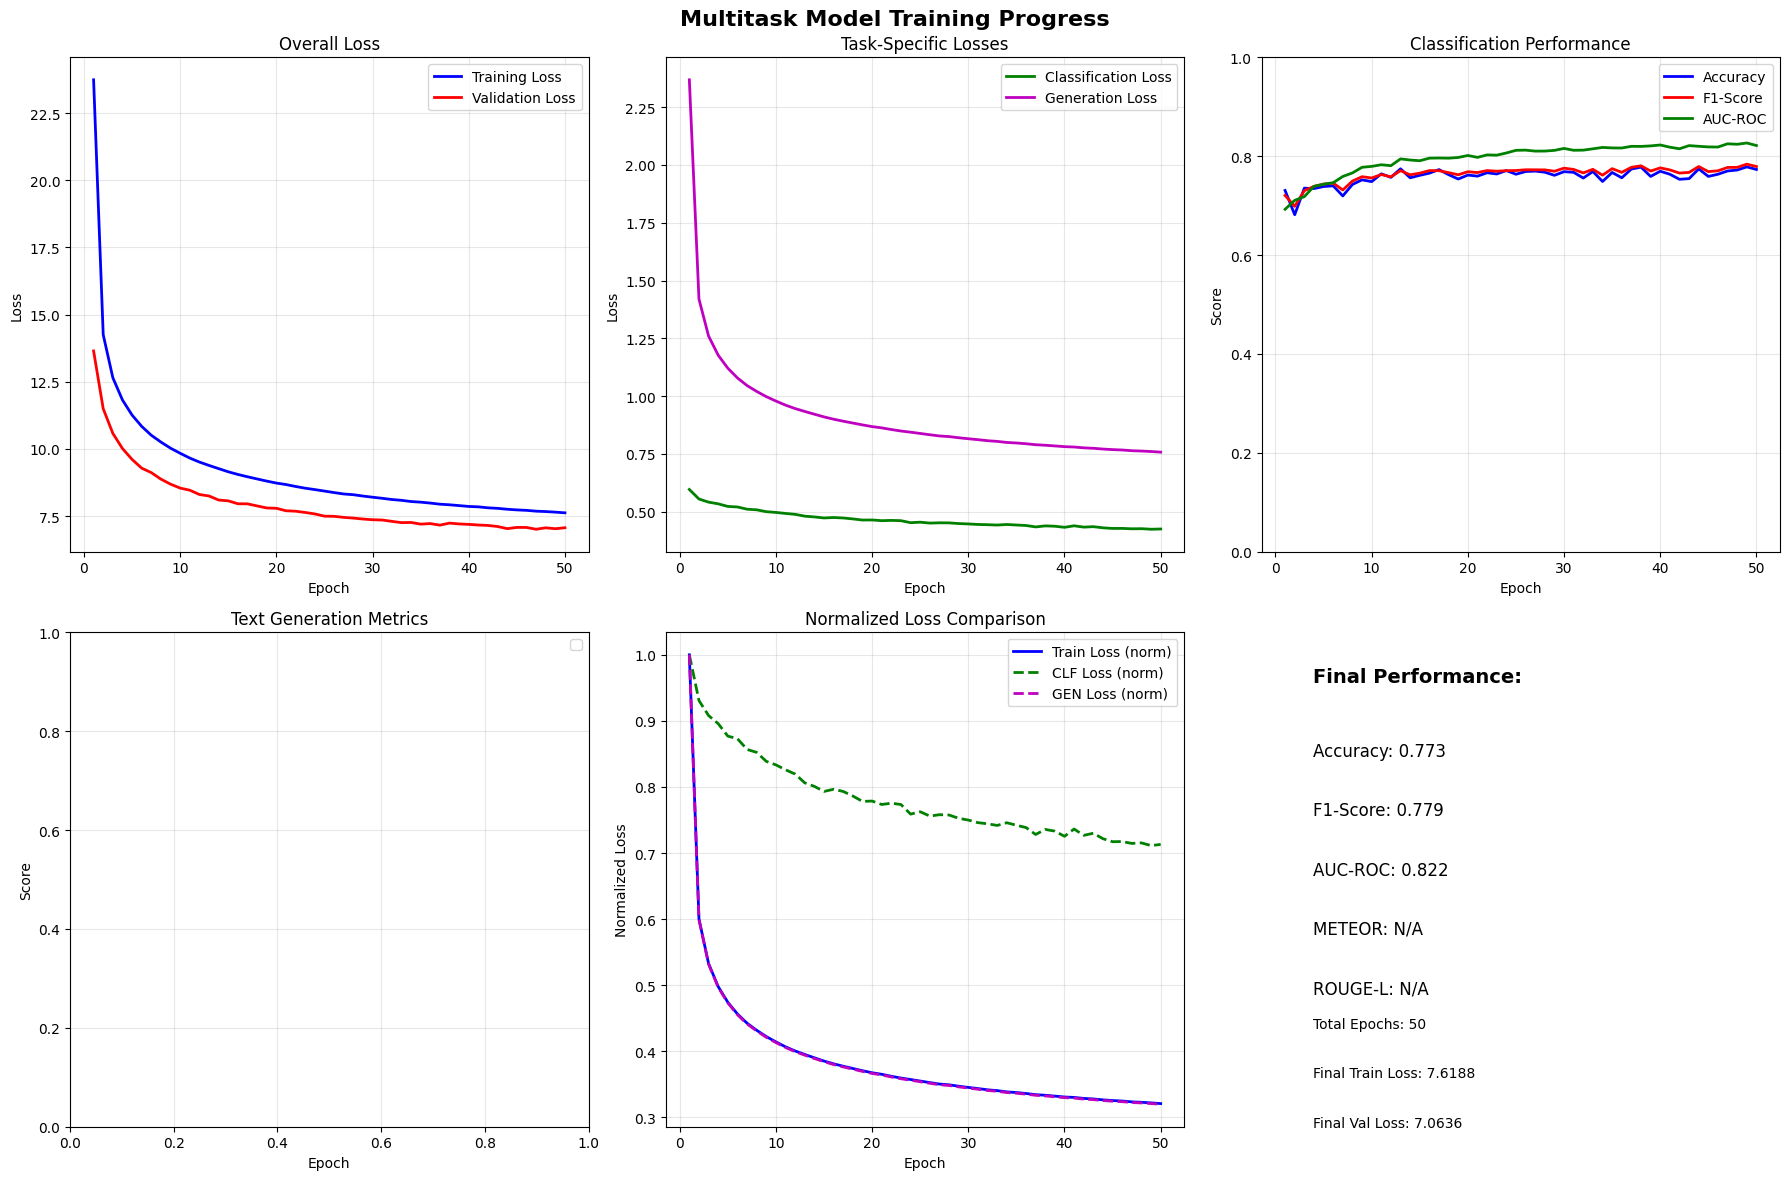


TRAINING SUMMARY
Best Accuracy: 0.7784
Best F1-Score: 0.7839
Best AUC-ROC: 0.8267


In [35]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [36]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 7.0207
Classification metrics (all 3625 samples):
  Accuracy     : 0.7939
  F1-Score     : 0.7991
  Sensitivity  : 0.8370
  Specificity  : 0.6587
  AUC-ROC      : 0.8456

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3684
  METEOR       : 0.3595

Sample efficiency: 3625/3625 samples used for text metrics


In [37]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 3588
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate locally elevated metabolism in the breast tissue. We recommend regular self-examination and a follow-up breast scan in 1 year (06. 2010). In case of noticeable, visible changes, discharge, or prolonged pain, we recommend a
Reference : The measured temperature in both breasts does not indicate pathological activity in the breasts. I recommend monthly self-examinations and a systematic examination one year later, 7-10 days after menstruation.
----------------------------------------

Sample 2948
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, currently above the recommended values, but its distribution currently does not indicate signs of locally higher metabolism in breast tissue. We recommend the next check-up in 1 year (04. 20

In [9]:
# import hierarchical modules
from models.hierarchy import (
    HierarchicalFeatureEncoder,        
    HierarchicalClassifier,           
    HierarchicalFeatureProjector,     
    HierarchicalMultitaskModel,       
    HierarchicalDataset,              
    create_hierarchical_pipeline      
)

In [10]:
# concat full text + hierarchical

In [12]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_hierarchical_pipeline(
    train_df, val_df,test_df,
    projection_mode='concat',          
    projection_type='mlp',             
    tokenizer_path='./t5-small-local/',
    batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    classification_weight=1.0,
    generation_weight=10.0,
    device_override=None
)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565



HIERARCHICAL MULTITASK MODEL
Architecture: Hierarchical encoder + CONCAT projection (mlp)
Classification weight: 1.0
Generation weight: 10.0
Using device: cuda
Model configuration:
  Hierarchical levels: 3 + integration
  Projection mode: concat
  Projection type: mlp
  Feature projection: Yes
  Feature dimensions: L1=256, L2=512, L3=512



Epoch 1/50


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Training loss: 19.1238
Classification loss: 0.5599
Generation loss: 1.8564
Weighted gen loss: 18.563865
Validation loss: 11.2458
Validation metrics:
  Accuracy     : 0.7530
  F1-Score     : 0.7515
  Sensitivity  : 0.8427
  Specificity  : 0.4721
  AUC-ROC      : 0.7462
✓ New best accuracy: 0.7530
✓ New best F1: 0.7515
✓ New best AUC-ROC: 0.7462

Epoch 2/50
Training loss: 11.7527
Classification loss: 0.5084
Generation loss: 1.1244
Weighted gen loss: 11.244272
Validation loss: 9.6677
Validation metrics:
  Accuracy     : 0.7467
  F1-Score     : 0.7551
  Sensitivity  : 0.7954
  Specificity  : 0.5941
  AUC-ROC      : 0.7677
✓ New best F1: 0.7551
✓ New best AUC-ROC: 0.7677

Epoch 3/50
Training loss: 10.5114
Classification loss: 0.4972
Generation loss: 1.0014
Weighted gen loss: 10.014181
Validation loss: 9.1052
Validation metrics:
  Accuracy     : 0.7511
  F1-Score     : 0.7571
  Sensitivity  : 0.8100
  Specificity  : 0.5667
  AUC-ROC      : 0.7754
✓ New best F1: 0.7571
✓ New best AUC-ROC: 0.7

Training loss: 6.8968
Classification loss: 0.3949
Generation loss: 0.6502
Weighted gen loss: 6.501870
Validation loss: 6.6126
Validation metrics:
  Accuracy     : 0.7721
  F1-Score     : 0.7796
  Sensitivity  : 0.8125
  Specificity  : 0.6454
  AUC-ROC      : 0.8255

Epoch 27/50
Training loss: 6.8449
Classification loss: 0.3960
Generation loss: 0.6449
Weighted gen loss: 6.448816
Validation loss: 6.5669
Validation metrics:
  Accuracy     : 0.7787
  F1-Score     : 0.7833
  Sensitivity  : 0.8322
  Specificity  : 0.6112
  AUC-ROC      : 0.8265
Current loss weights - CLF: 1.000, GEN: 10.000

Epoch 28/50
Training loss: 6.8012
Classification loss: 0.3958
Generation loss: 0.6405
Weighted gen loss: 6.405458
Validation loss: 6.5282
Validation metrics:
  Accuracy     : 0.7699
  F1-Score     : 0.7771
  Sensitivity  : 0.8133
  Specificity  : 0.6340
  AUC-ROC      : 0.8237

Epoch 29/50
Training loss: 6.7701
Classification loss: 0.3945
Generation loss: 0.6376
Weighted gen loss: 6.375533
Validation los

/home/s2080063/MWR-to-Text/dynamic.py:1062: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


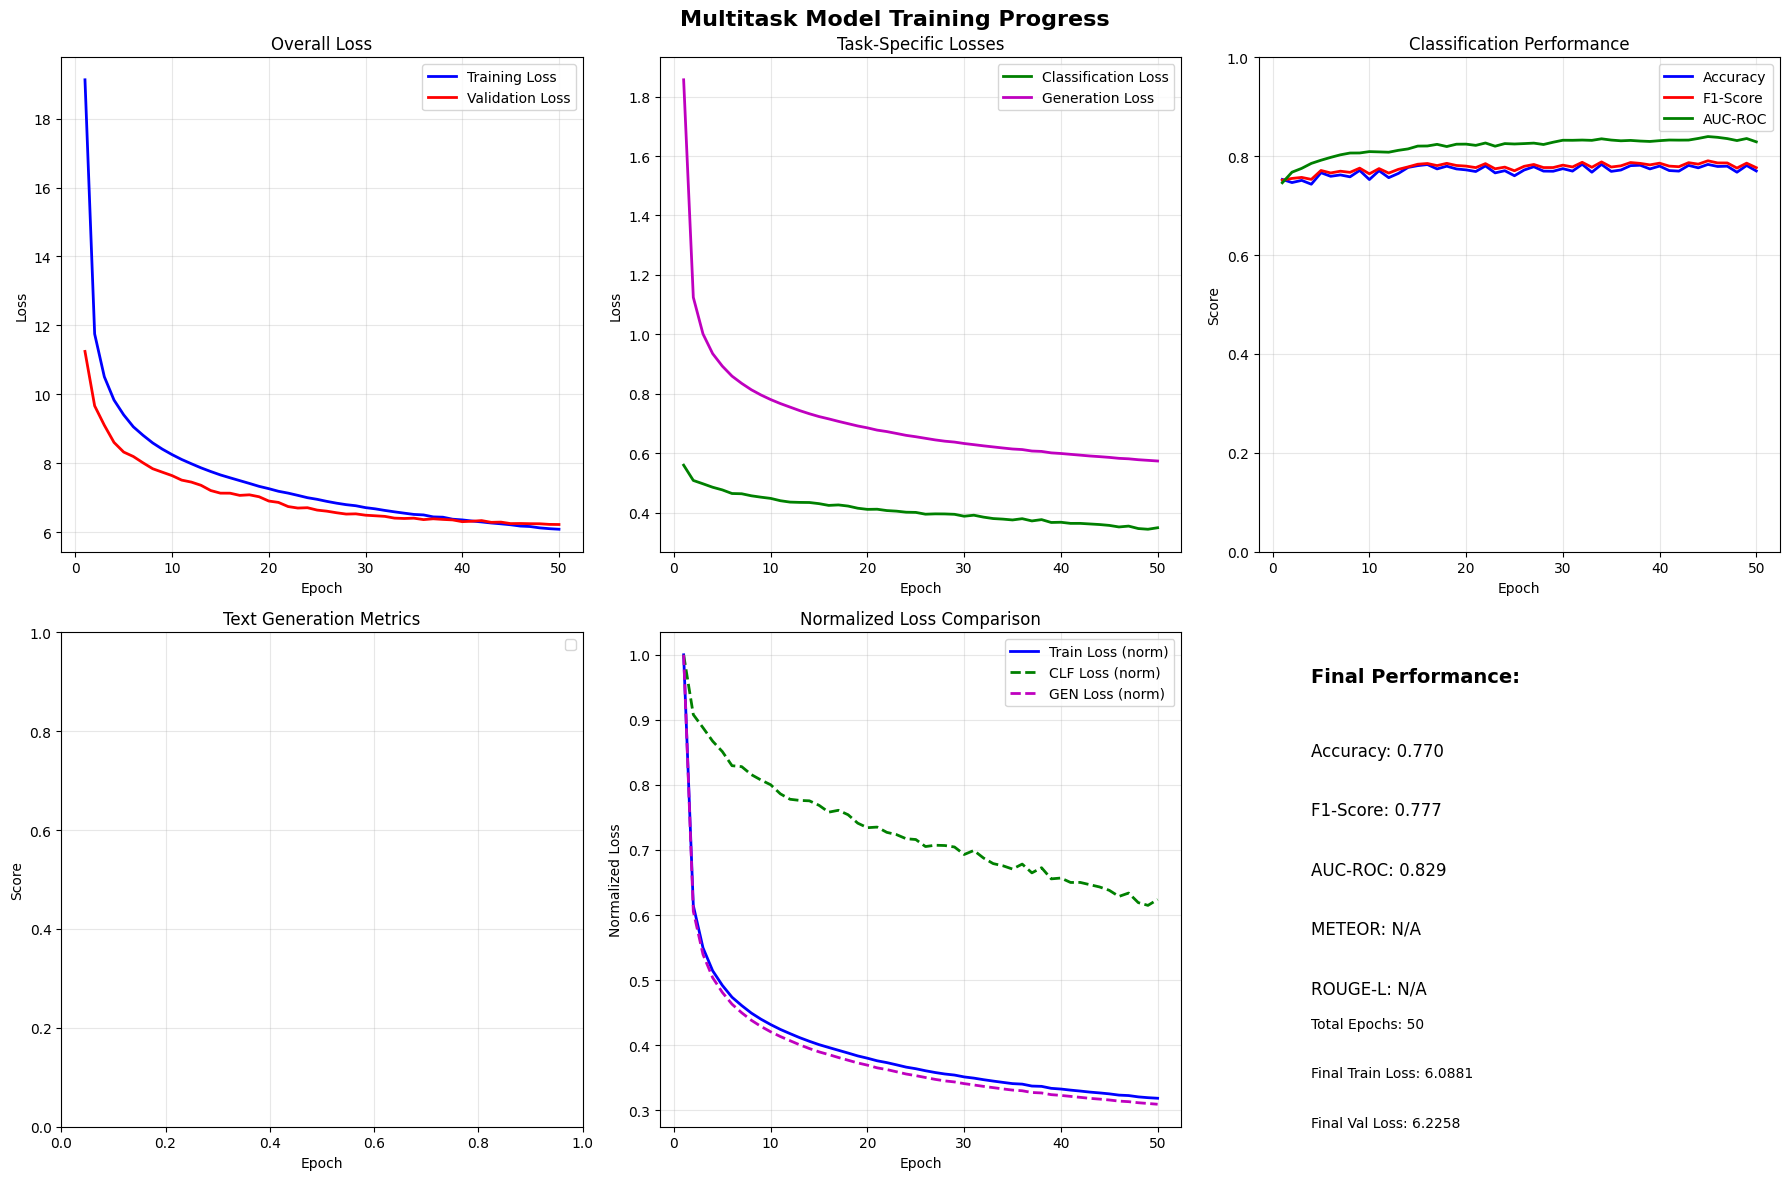


TRAINING SUMMARY
Best Accuracy: 0.7837
Best F1-Score: 0.7907
Best AUC-ROC: 0.8398


In [13]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [14]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.1893
Classification metrics (all 3625 samples):
  Accuracy     : 0.7895
  F1-Score     : 0.7967
  Sensitivity  : 0.8225
  Specificity  : 0.6861
  AUC-ROC      : 0.8489

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3689
  METEOR       : 0.3622

Sample efficiency: 3625/3625 samples used for text metrics


In [15]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 2620
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate locally elevated metabolism in the breast tissue. We recommend a follow-up in 1 year (November 2012). During this period, we advise monthly self-examinations and preventive check-ups with a specialist. In
Reference : The measured temperature values are not exceeded, and there are no signs of locally increased metabolism in the breast tissue.
----------------------------------------

Sample 457
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, currently above the recommended value, therefore we recommend repeating the measurement in 6 months (09.2016). During this period, we advise the lady to perform regular self-examinations and schedule a preventive mammogram, as well as to undergo
Reference : The measured temperature is asymme

In [16]:
tokenizer, train_loader, val_loader, test_loader, model, optimizer, device = create_hierarchical_pipeline(
    train_df, val_df, test_df,
    projection_mode='prefix',          
    projection_type='linear',             
    tokenizer_path='./t5-small-local/',
    batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    classification_weight=1.0,
    generation_weight=10.0,
    device_override=None
)


HIERARCHICAL MULTITASK MODEL
Architecture: Hierarchical encoder + PREFIX projection (linear)
Classification weight: 1.0
Generation weight: 10.0
Using device: cuda
Model configuration:
  Hierarchical levels: 3 + integration
  Projection mode: prefix
  Projection type: linear
  Feature projection: Yes
  Feature dimensions: L1=256, L2=512, L3=512



Epoch 1/50
Training loss: 19.0791
Classification loss: 0.5655
Generation loss: 1.8514
Weighted gen loss: 18.513597
Validation loss: 10.9418
Validation metrics:
  Accuracy     : 0.7677
  F1-Score     : 0.7541
  Sensitivity  : 0.8904
  Specificity  : 0.3831
  AUC-ROC      : 0.7451
✓ New best accuracy: 0.7677
✓ New best F1: 0.7541
✓ New best AUC-ROC: 0.7451

Epoch 2/50
Training loss: 11.5976
Classification loss: 0.5106
Generation loss: 1.1087
Weighted gen loss: 11.087004
Validation loss: 9.5580
Validation metrics:
  Accuracy     : 0.7740
  F1-Score     : 0.7712
  Sensitivity  : 0.8620
  Specificity  : 0.4983
  AUC-ROC      : 0.7736
✓ New best accuracy: 0.7740
✓ New best F1: 0.7712
✓ New best AUC-ROC: 0.7736

Epoch 3/50
Training loss: 10.4516
Classification loss: 0.4924
Generation loss: 0.9959
Weighted gen loss: 9.959243
Validation loss: 8.9399
Validation metrics:
  Accuracy     : 0.7646
  F1-Score     : 0.7672
  Sensitivity  : 0.8340
  Specificity  : 0.5473
  AUC-ROC      : 0.7815
✓ New 

Training loss: 6.8848
Classification loss: 0.4035
Generation loss: 0.6481
Weighted gen loss: 6.481248
Validation loss: 6.5677
Validation metrics:
  Accuracy     : 0.7861
  F1-Score     : 0.7900
  Sensitivity  : 0.8402
  Specificity  : 0.6169
  AUC-ROC      : 0.8331
✓ New best accuracy: 0.7861
✓ New best F1: 0.7900
✓ New best AUC-ROC: 0.8331
Current loss weights - CLF: 1.000, GEN: 10.000

Epoch 28/50
Training loss: 6.8436
Classification loss: 0.4000
Generation loss: 0.6444
Weighted gen loss: 6.443585
Validation loss: 6.5328
Validation metrics:
  Accuracy     : 0.7864
  F1-Score     : 0.7908
  Sensitivity  : 0.8376
  Specificity  : 0.6260
  AUC-ROC      : 0.8302
✓ New best accuracy: 0.7864
✓ New best F1: 0.7908

Epoch 29/50
Training loss: 6.7939
Classification loss: 0.3988
Generation loss: 0.6395
Weighted gen loss: 6.395044
Validation loss: 6.5066
Validation metrics:
  Accuracy     : 0.7779
  F1-Score     : 0.7839
  Sensitivity  : 0.8242
  Specificity  : 0.6328
  AUC-ROC      : 0.8258

E

/home/s2080063/MWR-to-Text/dynamic.py:1062: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


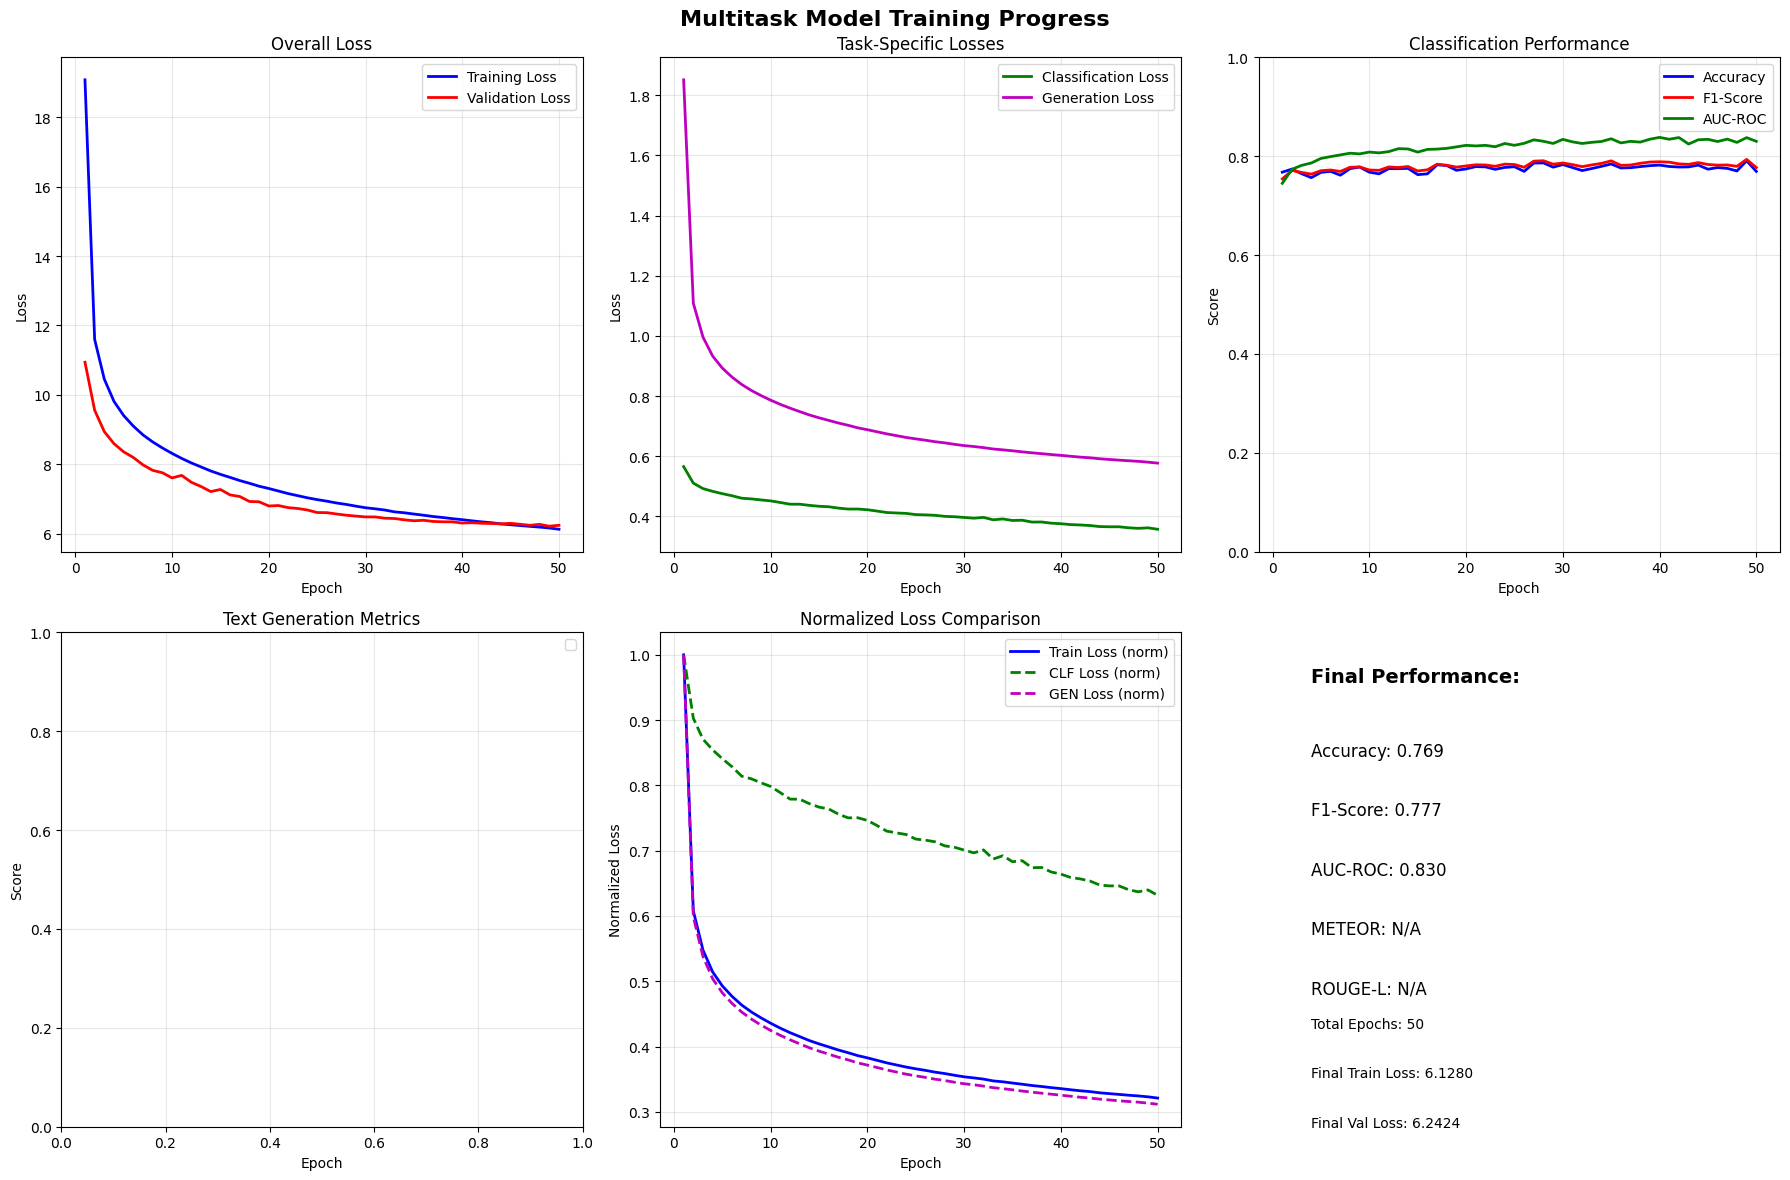


TRAINING SUMMARY
Best Accuracy: 0.7908
Best F1-Score: 0.7936
Best AUC-ROC: 0.8381


In [17]:
best_accuracy, best_f1, best_auc, best_meteor, best_rougeL = train_and_validate_model_with_meteor_rouge(
    model, train_loader, val_loader, optimizer, device, tokenizer, num_epochs=50, meteor_every=100
)

In [18]:
test_loss_sampled, test_metrics_sampled = print_test_evaluation(model, test_loader, device, tokenizer, test_df)


Training completed!
Best results from validation:

FINAL TEST SET EVALUATION

1. Full Classification Performance:
Test loss: 6.1513
Classification metrics (all 3625 samples):
  Accuracy     : 0.7892
  F1-Score     : 0.7956
  Sensitivity  : 0.8276
  Specificity  : 0.6689
  AUC-ROC      : 0.8512

2. Sampled Text Generation Performance:
Evaluating text generation on FULL dataset (3625 samples)
Computing text metrics on 3625 samples...
Text generation metrics (3625 samples):
  ROUGE-L F1   : 0.3931
  METEOR       : 0.3922

Sample efficiency: 3625/3625 samples used for text metrics


In [19]:
display_generated_texts(test_metrics_sampled['generated_texts'], test_metrics_sampled['reference_texts'], num_samples=50)


Displaying 50 randomly selected text generation samples:

Sample 380
----------------------------------------
Generated : The measured temperature is asymmetrically distributed, but does not indicate signs of locally elevated metabolism in the breast tissue. We advise regular self-examinations, regular recommended clinical examinations by a specialist doctor, and a mammogram according to his opinion, as well as a repeat breast
Reference : The measured temperature values are exceeded, but the current distribution of larger markers of locally higher metabolism in breast tissue does not indicate.
----------------------------------------

Sample 1557
----------------------------------------
Generated : The measured temperature is still asymmetrically distributed, and there are no significant signs of locally increased metabolism in the breast tissue. We recommend a follow-up check in 6-12 months (from November 2011 to June 2011), depending on the results of other diagnostics. During this 